# 3. Feladatsor
*(Normálegyenlet, iteratív megoldók, gradiens-ereszkedés)*

## Normálegyenlet

Az $Ax = b$ egyenlet $\| \cdot \|_2$ szerinti legjobb megoldása, azaz a $b$ vektor vetülete $\operatorname{ran}(A)$-ra. Ekkor az $Ax - b$ hibavektor merőleges az $A$ képterére, azaz $A^*$ magjában van, tehát
$$
A^*(Ax -b) = 0.
$$

### 1. Feladat

Legyen
$$
A = \begin{bmatrix}
    1 & 0 \\
    0 & 1 \\
    0 & 0
    \end{bmatrix}.
$$

a) Mi $A$ képtere?

b) Mi $A^*$ magja?

c) Mi az $A x = [1, 1, 1]^T$ 2-es norma szerinti legjobb megoldása, geometrialiag?

d) Írjuk fel a normálegyenletet és oldjuk is meg.

## Iteratív megoldók

**Tétel (Banach-fixpont)**: Ha $X$ teljes metrikus tér, $f: X \to X$ kontrakció, akkor $f$-nek pontosan egy fixpontja van, továbbá tetszőleges $x_0$  esetén az $x_{n+1} = f(x_n)$ képlettel definiált sorozat tart ehhez a fixponthoz.

**Következmény:** Ha $f: V \to V$ kontrakció egy adott normában, azaz Lipschitz-folytonos és a megfelelő $0 \leq L < 1$ konstans mellett minden $x,y \in V$ pontra $\|f(x) - f(y)\| \leq L \| x - y\|$ teljesül, akkor $f$-nek van fixpontja és tetszőleges kezdőpontból indulva, az $f$ ismételt alkalmazásával tartani tudunk ehhez.

**Példa:**
$f(x) = \frac12 x$ esetén $f(0) = 0$, és $x_n = 2^{-n} x_0$ nullához tart.

**Példa:** Ha $f(x) = Ax + b$ alakú, azaz affin függvény, akkor adódik, hogy
$$ \| f(x) - f(y) \| \leq \| A \| \|x - y\|, $$

tehát amennyiben $A$ operátornormája kisebb mint egy, akkor $f$ kontrakció. Végesdimenzióban $A$ egy mátrix, $b$ egy oszlopvektor, $\|A\|$ az $A$ indukált mátrixnormája.

**Következmény:** Egy affin függvény iterálásával kapott sorozat végesdimenzióban konvergens lesz ha van olyan norma, ami által indukált operátornormája a függvényben szereplő mátrixnak kisebb, mint $1$.

**Tétel:** $$\rho(A) = \sup_{\lambda \in \sigma(A)} |\lambda| = \inf\{\| A\| : \| \cdot \| \text{ indukált mátrixnorma}\}$$

**Következmény:** Ha $\rho(A) < 1$, akkor a megfelelő affin függvény iterálásával kapott sorozat konvergens, hiszen van olyan indukált mátrixnorma, amivel $\rho(A) \leq \|A\| < \rho(A) + \epsilon < 1$. ($\rho(A)=\|A\|_2$, ha $A$ SZPD)

**Ötlet:** Ha az $Ax = b$ egyenletet szeretnénk megoldani, akkor készítsünk olyan $f$ kontrakciót, amelynek $x^*$ fixpontjára $Ax^* = b$.

### Hogyan készíthetünk ilyen fixpont-iterációt I.

Legegyszerűbb megközelités (egyszerű- vagy **Richardson-iteráció**)
$$
\begin{align}
Ax &= b\\
0 &= b - Ax \\
x &= x - Ax + b \\
\\
f(x) &= (I-A)x +b
\end{align}
$$

Egy gond ezzel, hogy sokszor az $I-A$ mátrix spektrálsugara még nem elég kicsi. Ezen segithetünk egy $\omega$ paraméter bevezetésével:
$$
\begin{align}
Ax &= b\\
0 &= \omega(b - Ax) \\
x &= x - \omega Ax + \omega b \\
\\
f_{\omega}(x) &= (I-\omega A)x +\omega b
\end{align}
$$

Itt $\rho(I-\omega A) < 1$ pontosan akkor teljesül, ha az $A$ mátrix $\lambda$ sajátértékeire $| 1 - \omega \lambda | < 1$. A konvergencia akkor a leggyorsabb, ha ez a spektrálsugár minél kisebb. Például ha az $A$ mátrix szimmetrikus és pozitiv definit akkor az optimális választás $\omega$-ra: 

$$\omega_{\text{opt}} = \frac{2}{\lambda_{\min} + \lambda_{\max}}.$$

### 2. Feladat

Miért ez az $\omega_{\text{opt}}$?

$\rho(I-\omega A)=\max\{|1-\omega \lambda_{\min}|,|1-\omega \lambda_{\max}|\}$ SZPD $A$ esetén...

### Hogyan készíthetünk ilyen fixpont-iterációt II.

A fenti átalakitás általánosítása, ha $A=M-N$ felbontással élünk, majd ezzel számolunk.
    
$$
\begin{align}
Ax &= b\\
(M-N)x &= b\\
Mx &= Nx + b\\
x &= M^{-1}N x + M^{-1} b\\
\\
f(x) &= M^{-1}N x + M^{-1} b
\end{align}
$$

Itt tehát az iterációs mátrix $B=M^{-1}N$ és ennek a spektrálsugarát már hatékonyabban tudjuk befolyásolni az $M, N$ alkalmas megválasztásával.

#### Nevezetes módszerek

Legyen $A = L+ D+ U$ egy felbontása az $A$ mátrixnak rendre szigorú alsóháromszög, diagonális, és szigorú felsőháromszög mátrixokra. 

 * **Jacobi** iteráció: $M = D$
 * Relaxált Jacobi (**JOR**): $ M = \frac1\omega D$
 * **Gauss-Seidel** iteráció: $M = D + L$
 * Relaxált Gauss-Seidel (**SOR**): $M = \frac1\omega D + L$

**Tétel:** Ha $A$ szigorúan diagonálisan domináns (SZDD), akkor a Jacobi és a Gauss-Seidel iteráció konvergens.

**Definíció:** Egy négyzetes mátrixot M-mátrixnak nevezünk, ha főátlóján kívül nempozitív elemei vannak, és van olyan elemenként pozitív vektor, melynek a mátrix általi képe szintén elemenként pozitív.

**Tétel:** Ha $A$ M-mátrix, akkor konvergens a JOR és az SOR $0 < \omega < 1$ esetén.


**Tétel:** Ha $A$ szimmetrikus és pozitív definit (SZPD), akkor konvergens az SOR iteráció $0 < \omega < 2$ esetén.

### 3. Feladat
Tekintsük az
$$
\left[\matrix{2 & -1 \cr -1 & 2}\right] x= \left[ \matrix{1 \cr 3} \right]
$$
egyenletet.

a) Melyik módszereket használhatjuk ennek iteratív megoldására?

b) Írjuk fel a JOR iterációhoz tartozó iterációs mátrixot. Hogy alakul ennek spektrálsugara az $\omega$ függvényeként? 

c) Milyen $\omega$ választással lesz a leggyorsabb a konvergencia?

## Gradiens-alapú módszerek

Bizonyos esetekben egy lineáris algebrai egyenletrendszer megoldása előáll mint egy megfelelő függvény minimumhelye.

### 4. Feladat

Legyen $\phi: V \mapsto \mathbb{R}$ definíciója 
$$\phi_{A,b}(x) = \dfrac{x^T A x}{2} - b^Tx.$$

Mutassuk meg az alábbiakat.

a) 
$$
\phi'_{A,b}(x) = \nabla \phi_{A,b} (x) =  \dfrac{(A + A^T)x}{2} - b
$$

b)

$$
\phi_{A,b}''(x) = \frac{A + A^T}{2}
$$

### 5. Feladat

Láttuk, hogy ha $A$ SZPD, akkor a Richardson-iteráció alkalmazható. Ebben az esetben gondoljuk meg a következőket.

a) Az $x$ megoldása az $Ax = b$ egyenletnek pontosan akkor, ha $x$ az $\phi_{A, b}$ funkcionál kritikus pontja. 

b) A Richardson-iteráció egy lépése valójában a 
$$x_{k+1} = x_k - \omega \phi'_{A, b} (x_k) $$
formulával írható le.

#### Gradiens-ereszkedés (vagy -módszer)
Legyen $\phi: V \to \mathbb{R}$. Ekkor az

$$
x_{k+1} = x_k - \alpha_k \nabla \phi(x_k)
$$

iterációt gradiens-ereszkedésnek nevezzük. Itt $\phi$ például konvex, folytonosan differenciálható funkcionál, melynek gradiense Lipschitz-folytonos; $\alpha_k > 0$ pedig a lépéshosszok.

### 6. Feladat

A Richardson-iteráció tehát tekinthető egy állandó lépéshosszú gradiens-ereszkedésnek, melyet a $\phi_{A, b}$ függvényre alkalmazunk. Hogyan válaszhatnánk meg ennél ügyesebben a lépéshosszainkat? Mutassuk meg, hogy egy $x$ ponton átmenő, $p$ irányvektorú egyenes mentén a $\phi_{A, b}$ függvény minimumhelye (előadás jegyzetben!)

$$x - \frac{p^T r}{p^T A p} p,$$

ahol $r = Ax - b$.

Azt mondjuk, hogy a $\phi: V \to \mathbb{R}$ funkcionál konvex, ha minden $x, y \in V$ és $0 \leq t \leq 1$ esetén 
$$
\phi(tx + (1-t)y) \leq t \phi(x) + (1-t)\phi(y),
$$
azaz az $x$ és $y$ pontokat összekötő szakasz $\phi$ függvény általi képe nem helyezkedik el feljebb, mint az $\phi(x)$ és $\phi(y)$ pontokat összekötő szakasz.

### 7.* Feladat

Legyen $\phi$ konvex. Mutassuk meg az alábbiakat.

a) Ha $\psi$ konvex, akkor $\phi + \psi$ konvex. Például $\psi(x) = b^T x + c$.

b) Ha $0 \leq r$, akkor $r\phi$ konvex.

c) $x \mapsto \phi(Ax + b)$ konvex.

### 8.* Feladat

a) Ha $A = e_ie_i^T$, ahol $e_i$ az $i.$ standard bázisvektor, akkor $\phi_{A, b}$ konvex.

b) Ha $\Lambda$ diagonális mátrix és elemenként nemnegatív, akkor $\phi_{\Lambda, b}$ konvex.

c) Ha $A$ pozitív szemidefinit, akkor $\phi_{A, b}$ konvex.

### 9.* Feladat

Ha $\phi$ konvex és folyt. diff.ható, akkor mutassuk meg az alábbiakat.

a*)

$$
\phi(y) \geq \phi(x) + \langle \phi'(x), y- x\rangle,
$$

azaz az érintősíkok a függvény grafikonja alatt helyezkednek el.

b) 
Ha $\phi'(x) = 0$, akkor $x$ globális minimumhely.

### 10. Feladat

a) Mutassunk egy olyan $\phi_{\tilde A, \tilde b}$ függvényt, melynek minimumhelye egybeesik az
$$
\| Ax - b \|^2_2
$$
függvény minimumhelyével.

b) Mutassuk meg, hogy $\| Ax - b \|^2_2$ konvex.

c) Mutassuk meg, hogy a normálegyenlet megoldása egybeesik a $\phi_{\tilde A, \tilde b}$ függvény gradiensének zérushelyével.

----

### P1. Feladat
Írjunk programot, amely egy $A$ SZPD mátrix esetén egy ábrán ábrázolja az $I-\omega A$ mátrix sajátértékeinek abszolútértékét az $\omega$ függvényeként. Bemeneti paraméterek lehetnek a mátrix sajátértékei.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

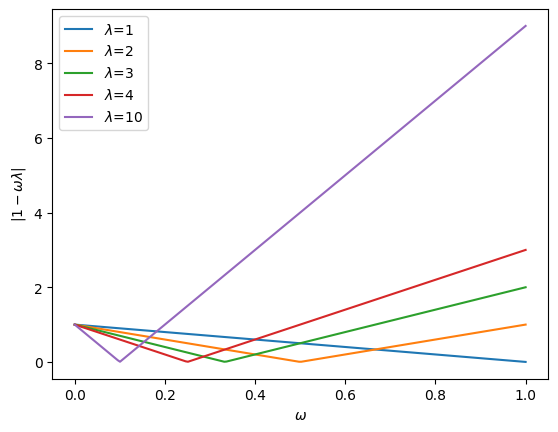

In [5]:
def vplot (lambdas, omega_min=0, omega_max=1):
    assert omega_max>omega_min

    ax=plt.axes()

    omegas = np.linspace(omega_min,omega_max,200)
    for lam in lambdas:
        ax.plot(omegas, abs(1-omegas*lam), label=fr"$\lambda$={lam}")

    ax.legend()
    ax.set_xlabel(r"$\omega$")
    ax.set_ylabel(r"$|1-\omega\lambda|$")

vplot([1,2,3,4,10])

### P2. Feladat
Írjunk általános függvényt a fenti, $A = M-N$ felbontással adódó iterációkhoz, majd ezzel implementáljuk a tanult iterációkat.

Alkalmazzunk is ezek közül egy olyat, amit értelmes az
$$
\left[\matrix{2 & -1 \cr -1 & 2}\right] x= \left[ \matrix{1 \cr 3} \right]
$$
egyenlet megoldására. Addig iteráljunk, míg két szomszédos iterált $\| \cdot \|_2$ szerinti távolsága $10^{-4}$ alá nem csökken.

In [2]:
import numpy as np
A=np.array([
    [2,-1],
    [-1,2],
])
b=np.array([1,3])
x=np.linalg.solve(A,b)
print(x)
x0=np.zeros((2,))

[1.66666667 2.33333333]


In [17]:
def Jacobi_iteration(A,b,x0,omega=1,atol=1e-4,max_step=1000):
    M=1/omega*np.diag(np.diag(A))
    N=M-A
    # B=M^{-1}N
    B=np.linalg.solve(M,N)
    # r=M^{-1}b
    r=np.linalg.solve(M,b)
    is_success=False
    x=x0
    for step_num in range (1,max_step):
        d=B@x+r-x;
        x=x+d
        itnum=step_num
        #ha d kicsi, akkor x_{n+1}-x_n kicsi, vagyis közel vagyunk a fixponthoz
        abs_err=np.linalg.norm(d)
        if abs_err<=atol:
            is_success=True
            
            break

    return x,itnum,is_success,M,N
    

In [18]:
Jacobi_iteration(A,b,x0)

(array([1.66659546, 2.33328247]),
 15,
 True,
 array([[2., 0.],
        [0., 2.]]),
 array([[0., 1.],
        [1., 0.]]))

In [19]:
def GS_iteration(A,b,x0,omega=1,atol=1e-4,max_step=1000):
    M=1/omega*np.diag(np.diag(A))+np.tril(A,-1)
    N=M-A
    # B=M^{-1}N
    B=np.linalg.solve(M,N)
    # r=M^{-1}b
    r=np.linalg.solve(M,b)
    is_success=False
    x=x0
    for step_num in range (1,max_step):
        d=B@x+r-x;
        x=x+d
        itnum=step_num
        #ha d kicsi, akkor x_{n+1}-x_n kicsi, vagyis közel vagyunk a fixponthoz
        abs_err=np.linalg.norm(d)
        if abs_err<=atol:
            is_success=True
            
            break

    return x,itnum,is_success,M,N

In [27]:
GS_iteration(A,b,x0)

(array([1.66664886, 2.33332443]),
 9,
 True,
 array([[ 2.,  0.],
        [-1.,  2.]]),
 array([[0., 1.],
        [0., 0.]]))

In [23]:
C=np.array([
    [2,-4],
    [-3,2],
])

x=np.linalg.solve(C,b)
print(x)

Jacobi_iteration(C.T@C,C.T@b,x0)

[-1.75  -1.125]


(array([-1.74972534, -1.12482343]),
 62,
 True,
 array([[13.,  0.],
        [ 0., 20.]]),
 array([[ 0., 14.],
        [14.,  0.]]))

In [24]:
GS_iteration(C.T@C,C.T@b,x0)

(array([-1.74980985, -1.12486689]),
 32,
 True,
 array([[ 13.,   0.],
        [-14.,  20.]]),
 array([[ 0., 14.],
        [ 0.,  0.]]))

### P3.* Feladat

Írjunk programot, amit adott $\lambda_1, \lambda_2$ valós sajátértékek és $q_1, q_2$ egymásra merőleges sajátvektorok esetén ábrázolja a megfelelő kvadratikus alakot, azaz a

$$
\mathbb{R}^2 \ni x \mapsto x^T A x
$$
függvényt, ahol $A = \lambda_1 q_1 q_1^T + \lambda_2 q_2 q_2^T$. Ábrázoljunk a sajátértékek előjele szerinti lehetséges esetekre 1-1 példát.

### P4. Feladat

Implementáljuk a gradiens-módszert az optimális lépéshosszválasztással az SZPD-baloldalú lineáris egyenletrendszer iteratív megoldására.

Alkalmazzuk is ezt a módszert az 
$$
\left[\matrix{2 & -1 \cr -1 & 2}\right] x= \left[ \matrix{1 \cr 3} \right]
$$
egyenlet megoldására. Addig iteráljunk, míg két szomszédos iterált $\| \cdot \|_\infty$ szerinti távolsága $10^{-6}$ alá nem csökken.

In [32]:
def gradient_descent(A,b,x0,atol=1e-6,max_step=1000):

    is_success=False
    x=x0
    for it_num in range(max_step):
        r=A@x-b
        if np.linalg.norm(r,np.inf)<atol:
            is_success=True
            break

        omega=r@r/(r@(A@r))
        x=x-omega*r
    return x,it_num+1,is_success


In [36]:
gradient_descent(A,b,x0)

(array([1.6666664 , 2.33333296]), 19, True)